# 13 · Final evaluation: the test set, used once (Step 15)

**Goal:** the honest numbers. The 20% test split (61,502 applicants) has not been touched by any
step so far. Everything that could be chosen was chosen before this notebook:

- **Models:** the final tuned LightGBM and its reweighed version (Step 13) as saved, plus three
  reference models refitted once on the whole train split with their Step 6 settings: logistic
  regression, the glass-box EBM and the WoE points scorecard. (The MLP and XGBoost are left
  out: the MLP needs its torch training loop, XGBoost was within 0.003 of LightGBM in CV.)
- **Tests:** the final model against each of the other four on test: a paired bootstrap on
  ROC-AUC and McNemar on the decisions at the money threshold, each family Holm-corrected.
- **Decisions:** the Step 10 money rule and the Step 11 conformal cut-offs, unchanged.

**Part A (train split only):** learning curves and the 5x2cv t-test retrain models, so they
never see test. **Part B:** test predictions, made once, and every number after them.

**After this notebook nothing about the models changes.**

**Time:** about 20 minutes (the 5x2cv test trains 20 models).

**Saved results:**

- `reports/results_step15_test.csv` (the frozen table), `_comparisons.csv`, `_decisions.csv`,
  `_fairness.csv`, `_learning_curve.csv`, `_5x2cv.csv`
- `reports/figures/fig37_learning_curves.png`, `fig38_test_roc_calibration.png`

In [1]:
%load_ext autoreload
%autoreload 2

import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, roc_curve

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.decision.conformal import coverage, decide
from creditrisk.decision.threshold import realised_profit
from creditrisk.evaluation.bootstrap import bootstrap_ci, paired_bootstrap
from creditrisk.evaluation.metrics import evaluate, expected_calibration_error, ks_statistic
from creditrisk.evaluation.stats_tests import five_by_two_cv, holm, mcnemar
from creditrisk.fairness.audit import age_band, audit, gaps
from creditrisk.features.build import load_features
from creditrisk.models.data import column_groups, get_xy
from creditrisk.models.final import MODEL_DIR, load_final_model
from creditrisk.models.ladder import ladder_models

warnings.filterwarnings("ignore", message="Missing values detected")  # an EBM notice
SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
facts = {}

final_model, details = load_final_model()
cols = details["features"]
decision = json.loads((MODEL_DIR / "decision.json").read_text())
MARGIN, LGD, THRESHOLD = decision["margin"], decision["lgd"], decision["threshold"]
cuts = decision["conformal"]

features = load_features()
splits = load_splits()
X_tr, y_tr, folds, _ = get_xy(features, splits, "train")
X_tr = X_tr[cols]
builders = ladder_models(column_groups(X_tr), seed=SEED)
REFERENCE = ["logistic_regression", "ebm", "woe_scorecard"]
print(f"train: {len(y_tr):,} applicants | threshold {THRESHOLD:.4f} | "
      f"conformal: approve below {cuts['approve_below']:.4f}, decline above {cuts['decline_above']:.4f}")

train: 184,503 applicants | threshold 0.1667 | conformal: approve below 0.0355, decline above 0.1655


## A1. Learning curves (train split only)

Hold out fold 1; train on 2% to 100% of folds 2–5. ROC-AUC on the rows each model trained on
vs on the held-out fold. A gap that stays open means variance (more data still helps); two
curves that meet low mean bias.

,model,training rows,train ROC-AUC,held-out ROC-AUC
0,LightGBM (final settings),2952,0.9987,0.7187
1,logistic regression,2952,0.8557,0.7128
2,LightGBM (final settings),7380,1.0000,0.7363
3,logistic regression,7380,0.8298,0.7390
4,LightGBM (final settings),14760,0.9998,0.7502
5,logistic regression,14760,0.8117,0.7549
6,LightGBM (final settings),36900,0.9794,0.7726
7,logistic regression,36900,0.7920,0.7662
8,LightGBM (final settings),73801,0.9348,0.7843
9,logistic regression,73801,0.7861,0.7756


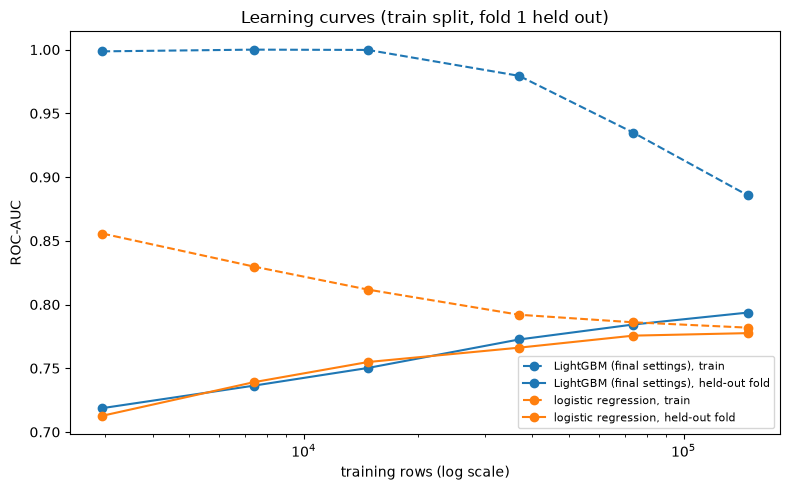

In [2]:
fit_pool, held = np.flatnonzero(folds != 1), np.flatnonzero(folds == 1)
rng = np.random.default_rng(SEED)
order = rng.permutation(fit_pool)
curve = []
for share in [0.02, 0.05, 0.1, 0.25, 0.5, 1.0]:
    rows = np.sort(order[: int(share * len(order))])
    for name, make in [("LightGBM (final settings)", lambda: clone(final_model)),
                       ("logistic regression", builders["logistic_regression"])]:
        m = make().fit(X_tr.iloc[rows], y_tr[rows])
        curve.append({"model": name, "training rows": len(rows),
                      "train ROC-AUC": roc_auc_score(y_tr[rows], m.predict_proba(X_tr.iloc[rows])[:, 1]),
                      "held-out ROC-AUC": roc_auc_score(y_tr[held], m.predict_proba(X_tr.iloc[held])[:, 1])})
curve = pd.DataFrame(curve)
display(curve.round(4))
curve.to_csv(REPORTS / "results_step15_learning_curve.csv", index=False)
facts["learning_curve"] = curve.round(4).to_dict(orient="records")

fig, ax = plt.subplots(figsize=(8, 5))
for i, (name, g) in enumerate(curve.groupby("model", sort=False)):
    ax.plot(g["training rows"], g["train ROC-AUC"], "o--", color=f"C{i}", label=f"{name}, train")
    ax.plot(g["training rows"], g["held-out ROC-AUC"], "o-", color=f"C{i}",
            label=f"{name}, held-out fold")
ax.set(xscale="log", xlabel="training rows (log scale)", ylabel="ROC-AUC",
       title="Learning curves (train split, fold 1 held out)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "fig37_learning_curves.png", dpi=150)
plt.show()

## A2. 5x2cv paired t-test: LightGBM vs logistic regression (train split only)

Five repetitions of a stratified 2-fold split of the train split; both models are trained on
one half and scored on the other. Dietterich (1998) showed this test keeps its false-alarm rate,
unlike a t-test over ordinary CV folds (whose training sets overlap).

In [3]:
result_5x2 = five_by_two_cv(lambda: clone(final_model), builders["logistic_regression"],
                            X_tr, y_tr, seed=SEED)
diffs = pd.DataFrame(result_5x2["differences"], columns=["half 1", "half 2"],
                     index=[f"repeat {i + 1}" for i in range(5)])
display(diffs.round(4))
print(f"mean ROC-AUC difference {result_5x2['mean_difference']:.4f}, "
      f"t = {result_5x2['t']:.2f} (5 df), p = {result_5x2['p_value']:.2g}")
diffs.assign(t=result_5x2["t"], p_value=result_5x2["p_value"]).to_csv(
    REPORTS / "results_step15_5x2cv.csv")
facts["5x2cv"] = {k: round(v, 6) for k, v in result_5x2.items() if k != "differences"}

,half 1,half 2
repeat 1,0.0109,0.0083
repeat 2,0.0099,0.0143
repeat 3,0.0108,0.0093
repeat 4,0.0123,0.0103
repeat 5,0.0132,0.0103


mean ROC-AUC difference 0.0110, t = 5.38 (5 df), p = 0.003


## B. The test split

The three reference models are fitted on the whole train split first; then every model predicts
the test split once.

In [4]:
models = {"LightGBM (final)": joblib.load(MODEL_DIR / "calibrated_final.joblib"),
          "LightGBM, reweighed": joblib.load(MODEL_DIR / "reweighed_final.joblib")}
names = {"logistic_regression": "logistic regression", "ebm": "EBM (glass box)",
         "woe_scorecard": "WoE scorecard"}
for key in REFERENCE:
    models[names[key]] = builders[key]().fit(X_tr, y_tr)

# ---- the test split is opened here, once ----
X_te, y_te, _, _ = get_xy(features, splits, "test", include_sensitive=True)
gender = X_te["APP_CODE_GENDER"].astype(str).to_numpy()
age = age_band(X_te["APP_AGE_YEARS"])
amount = X_te["APP_AMT_CREDIT"].to_numpy(dtype=float)
P = {name: m.predict_proba(X_te[cols])[:, 1] for name, m in models.items()}
print(f"test: {len(y_te):,} applicants, {y_te.sum():,} defaulters ({y_te.mean():.2%})")

test: 61,502 applicants, 4,965 defaulters (8.07%)


In [5]:
cv_auc = {"LightGBM (final)": details["cv_roc_auc"], "LightGBM, reweighed": np.nan}
ladder = pd.read_csv(REPORTS / "results_step6_ladder.csv").set_index("model")["ROC-AUC"]
cv_auc.update({names[k]: ladder[k] for k in REFERENCE})
METRICS = {"ROC-AUC": roc_auc_score, "PR-AUC": average_precision_score, "KS": ks_statistic,
           "Brier": brier_score_loss, "ECE": expected_calibration_error}
rows = {}
for name, p in P.items():
    row = {"CV ROC-AUC (train)": cv_auc[name]}
    for metric, fn in METRICS.items():
        ci = bootstrap_ci(y_te, p, metric=fn, n_boot=1000, seed=SEED)
        row[metric] = ci["estimate"]
        row[f"{metric} 95% CI"] = f"{ci['low']:.4f}-{ci['high']:.4f}"
    row["mean predicted"] = p.mean()
    rows[name] = row
test_table = pd.DataFrame(rows).T
test_table.index.name = "model"
display(test_table)
test_table.to_csv(REPORTS / "results_step15_test.csv")
facts["test"] = test_table.to_dict(orient="index")
assert all(abs(evaluate(y_te, p)["roc_auc"] - test_table.loc[n, "ROC-AUC"]) < 1e-12
           for n, p in P.items())

,CV ROC-AUC (train),ROC-AUC,ROC-AUC 95% CI,PR-AUC,PR-AUC 95% CI,KS,KS 95% CI,Brier,Brier 95% CI,ECE,ECE 95% CI,mean predicted
model,,,,,,,,,,,,
LightGBM (final),0.7899,0.79015,0.7837-0.7968,0.295321,0.2833-0.3087,0.439263,0.4281-0.4546,0.065278,0.0638-0.0667,0.001838,0.0011-0.0042,0.079909
"LightGBM, reweighed",NaN,0.790052,0.7835-0.7967,0.293712,0.2816-0.3072,0.441318,0.4291-0.4551,0.06534,0.0638-0.0668,0.002115,0.0012-0.0044,0.079698
logistic regression,0.7756,0.777572,0.7711-0.7845,0.272303,0.2605-0.2850,0.420484,0.4093-0.4348,0.066383,0.0649-0.0679,0.001637,0.0011-0.0042,0.080529
EBM (glass box),0.7764,0.780911,0.7744-0.7876,0.272998,0.2615-0.2861,0.428743,0.4173-0.4421,0.066274,0.0647-0.0678,0.002156,0.0013-0.0046,0.080667
WoE scorecard,0.7548,0.757486,0.7508-0.7645,0.238629,0.2277-0.2500,0.392059,0.3806-0.4070,0.06794,0.0663-0.0695,0.001846,0.0010-0.0042,0.080419


## B2. Is the final model really better? (Holm-corrected)

Paired bootstrap: the same 1,000 resamples of test applicants for both models. McNemar: at the
money threshold, a decision is right if a defaulter is declined or a repayer approved; only the
applicants where exactly one model is right count.

In [6]:
final = "LightGBM (final)"
correct = {n: (p >= THRESHOLD) == (y_te == 1) for n, p in P.items()}
comp = []
for other in [n for n in P if n != final]:
    pb = paired_bootstrap(y_te, P[final], P[other], n_boot=1000, seed=SEED)
    mc = mcnemar(correct[final], correct[other])
    comp.append({"vs": other, "ROC-AUC difference": pb["difference"],
                 "95% CI": f"{pb['low']:.4f} to {pb['high']:.4f}", "bootstrap p": pb["p_value"],
                 "decisions right, final": correct[final].mean(),
                 "decisions right, other": correct[other].mean(),
                 "only final right": mc["only_a_right"], "only other right": mc["only_b_right"],
                 "McNemar p": mc["p_value"]})
comp = pd.DataFrame(comp).set_index("vs")
comp["bootstrap p (Holm)"] = holm(comp["bootstrap p"])
comp["McNemar p (Holm)"] = holm(comp["McNemar p"])
display(comp)
comp.to_csv(REPORTS / "results_step15_comparisons.csv")
facts["comparisons"] = comp.to_dict(orient="index")

,ROC-AUC difference,95% CI,bootstrap p,"decisions right, final","decisions right, other",only final right,only other right,McNemar p,bootstrap p (Holm),McNemar p (Holm)
vs,,,,,,,,,,
"LightGBM, reweighed",0.000099,-0.0011 to 0.0012,0.858,0.865972,0.866086,724,731,0.875018,0.858,0.875018
logistic regression,0.012578,0.0100 to 0.0152,0.000,0.865972,0.862297,1832,1606,0.000124,0.000,0.000495
EBM (glass box),0.009239,0.0066 to 0.0116,0.000,0.865972,0.863891,1602,1474,0.022014,0.000,0.066041
WoE scorecard,0.032665,0.0290 to 0.0365,0.000,0.865972,0.863468,2394,2240,0.024593,0.000,0.066041


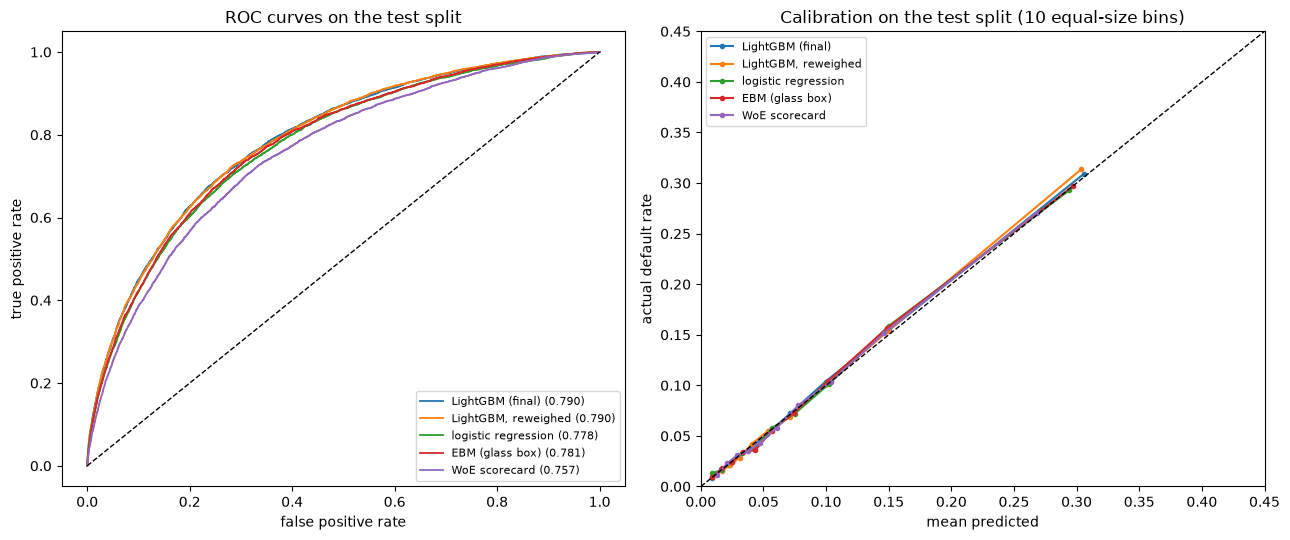

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name, p in P.items():
    fpr, tpr, _ = roc_curve(y_te, p)
    axes[0].plot(fpr, tpr, lw=1.3, label=f"{name} ({roc_auc_score(y_te, p):.3f})")
    frac, mean_p = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    axes[1].plot(mean_p, frac, "o-", ms=3, label=name)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(title="ROC curves on the test split", xlabel="false positive rate",
            ylabel="true positive rate")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].plot([0, 0.45], [0, 0.45], "k--", lw=1)
axes[1].set(title="Calibration on the test split (10 equal-size bins)", xlabel="mean predicted",
            ylabel="actual default rate", xlim=(0, 0.45), ylim=(0, 0.45))
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "fig38_test_roc_calibration.png", dpi=150)
plt.show()

## B3. Decisions on test: the money rule and the conformal guarantee

The validation numbers (Steps 10–11) are shown next to the test numbers. The conformal cut-offs
were fitted for the final model's scores, so they are applied to the final model only.

In [8]:
everyone = realised_profit(y_te, amount, np.ones(len(y_te), bool), MARGIN, LGD)
dec = {}
for name in ["LightGBM (final)", "LightGBM, reweighed"]:
    approved = P[name] < THRESHOLD
    profit = realised_profit(y_te, amount, approved, MARGIN, LGD)
    dec[name] = {"approval rate": approved.mean(),
                 "defaulters declined": 1 - approved[y_te == 1].mean(),
                 "good customers declined": 1 - approved[y_te == 0].mean(),
                 "profit (millions)": profit / 1e6,
                 "profit vs approving everyone": profit / everyone - 1}
d = decide(P[final], cuts["q_repay"], cuts["q_default"])
cov = coverage(P[final], y_te, cuts["q_repay"], cuts["q_default"])
dec[final].update({"conformal coverage repay": cov["repay"],
                   "conformal coverage default": cov["default"],
                   "defaulters auto-approved": np.mean(d[y_te == 1] == "approve"),
                   "good customers auto-declined": np.mean(d[y_te == 0] == "decline"),
                   **{f"share {k}": np.mean(d == k) for k in ("approve", "refer", "decline")}})
decisions = pd.DataFrame(dec)
step11 = pd.read_csv(REPORTS / "results_step11_coverage.csv", header=[0, 1], index_col=0)
step11 = step11[("validation", "one per class")].rename(
    {"coverage repay": "conformal coverage repay", "coverage default": "conformal coverage default"})
decisions["validation (Steps 10-11)"] = pd.concat([pd.Series({
    k: decision["validation"][k] for k in
    ("approval rate", "defaulters declined", "good customers declined")}), step11])
display(decisions.round(4))
print(f"approving everyone on test: {everyone / 1e6:,.1f}M")
decisions.to_csv(REPORTS / "results_step15_decisions.csv")
facts["decisions"] = decisions.round(4).to_dict()

,LightGBM (final),"LightGBM, reweighed",validation (Steps 10-11)
approval rate,0.8751,0.8765,0.8744
defaulters declined,0.4437,0.4356,0.4452
good customers declined,0.0969,0.0961,0.0975
profit (millions),2314.6439,2301.8629,NaN
profit vs approving everyone,0.1385,0.1322,NaN
conformal coverage repay,0.9017,NaN,0.9015
conformal coverage default,0.9017,NaN,0.9069
defaulters auto-approved,0.0983,NaN,0.0931
good customers auto-declined,0.0983,NaN,0.0985
share approve,0.4048,NaN,0.4024


approving everyone on test: 2,033.0M


## B4. Fairness on test (final vs reweighed)

The Step 13 audit, repeated once on test: gender and age band at the money rule, plus
calibration within gender (the price reweighing paid on validation).

In [9]:
fair = {}
for name in ["LightGBM (final)", "LightGBM, reweighed"]:
    approved = P[name] < THRESHOLD
    for attr, g in {"gender": gender, "age band": age}.items():
        t = audit(y_te, P[name], g, approved)
        for group, r in t.iterrows():
            fair[(name, attr, group)] = r.to_dict()
        fair[(name, attr, "gap")] = gaps(t)
fairness = pd.DataFrame(fair).T
fairness.index.names = ["model", "attribute", "group"]
cols_show = ["default rate", "mean predicted", "ROC-AUC", "approval rate",
             "good customers declined", "defaulters declined", "equal opportunity gap",
             "demographic parity difference", "disparate impact ratio"]
display(fairness[cols_show].astype(float).round(4))
fairness.to_csv(REPORTS / "results_step15_fairness.csv")
facts["fairness"] = {str(k): v for k, v in fairness[cols_show].astype(float).round(4)
                     .to_dict(orient="index").items()}

default rate  mean predicted  ROC-AUC  \
model               attribute group                                          
LightGBM (final)    gender    F            0.0699          0.0727   0.7864   
                              M            0.1016          0.0939   0.7864   
                              gap             NaN             NaN      NaN   
                    age band  <30          0.1124          0.1162   0.7565   
                              30-45        0.0882          0.0871   0.7997   
                              45-60        0.0687          0.0664   0.7851   
                              60+          0.0499          0.0486   0.7432   
                              gap             NaN             NaN      NaN   
LightGBM, reweighed gender    F            0.0699          0.0762   0.7878   
                              M            0.1016          0.0865   0.7880   
                              gap             NaN             NaN      NaN   
                    age band  <30          0.1124          0.1144   0.7582   
                              30-45        0.0882          0.0864   0.7991   
                              45-60        0.0687          0.0665   0.7841   
                              60+          0.0499          0.0510   0.7471   
                              gap             NaN             NaN      NaN   

                                     approval rate  good customers declined  \
model               attribute group                                           
LightGBM (final)    gender    F             0.8955                   0.0815   
                              M             0.8356                   0.1278   
                              gap              NaN                      NaN   
                    age band  <30           0.7657                   0.1945   
                              30-45         0.8569                   0.1103   
                              45-60         0.9144                   0.0647   
                              60+           0.9618                   0.0293   
                              gap              NaN                      NaN   
LightGBM, reweighed gender    F             0.8872                   0.0893   
                              M             0.8558                   0.1097   
                              gap              NaN                      NaN   
                    age band  <30           0.7743                   0.1870   
                              30-45         0.8589                   0.1088   
                              45-60         0.9138                   0.0658   
                              60+           0.9578                   0.0334   
                              gap              NaN                      NaN   

                                     defaulters declined  \
model               attribute group                        
LightGBM (final)    gender    F                   0.4101   
                              M                   0.4885   
                              gap                    NaN   
                    age band  <30                 0.5487   
                              30-45               0.4822   
                              45-60               0.3694   
                              60+                 0.2073   
                              gap                    NaN   
LightGBM, reweighed gender    F                   0.4249   
                              M                   0.4500   
                              gap                    NaN   
                    age band  <30                 0.5318   
                              30-45               0.4748   
                              45-60               0.3637   
                              60+                 0.2101   
                              gap                    NaN   

                                     equal opportunity gap  \
model               attribute group                          
Ligh

In [10]:
for key, value in facts.items():
    print(f"{key}: {value}")

learning_curve: [{'model': 'LightGBM (final settings)', 'training rows': 2952, 'train ROC-AUC': 0.9987, 'held-out ROC-AUC': 0.7187}, {'model': 'logistic regression', 'training rows': 2952, 'train ROC-AUC': 0.8557, 'held-out ROC-AUC': 0.7128}, {'model': 'LightGBM (final settings)', 'training rows': 7380, 'train ROC-AUC': 1.0, 'held-out ROC-AUC': 0.7363}, {'model': 'logistic regression', 'training rows': 7380, 'train ROC-AUC': 0.8298, 'held-out ROC-AUC': 0.739}, {'model': 'LightGBM (final settings)', 'training rows': 14760, 'train ROC-AUC': 0.9998, 'held-out ROC-AUC': 0.7502}, {'model': 'logistic regression', 'training rows': 14760, 'train ROC-AUC': 0.8117, 'held-out ROC-AUC': 0.7549}, {'model': 'LightGBM (final settings)', 'training rows': 36900, 'train ROC-AUC': 0.9794, 'held-out ROC-AUC': 0.7726}, {'model': 'logistic regression', 'training rows': 36900, 'train ROC-AUC': 0.792, 'held-out ROC-AUC': 0.7662}, {'model': 'LightGBM (final settings)', 'training rows': 73801, 'train ROC-AUC': 

## Findings (frozen)

- **CV told the truth.** The final LightGBM scores **ROC-AUC 0.790 (95% CI 0.784–0.797)** on the 61,502 untouched test applicants, the same as its 5-fold CV estimate (0.790). Every reference model also lands within 0.005 of its CV number (logistic regression 0.778, EBM 0.781, scorecard 0.757), so neither tuning nor model choice overfitted the folds. PR-AUC 0.295, KS 0.439, Brier 0.0653.
- **Still calibrated:** mean predicted 7.99% vs 8.07% actual; ECE 0.0018 (CI 0.0011–0.0042). All five models are calibrated (figure 38), so the money threshold means the same thing for each.
- **Is LightGBM really better? On ranking, yes:** paired bootstrap on test, Holm-corrected: +0.013 vs logistic regression (CI 0.010 to 0.015), +0.009 vs EBM (0.007 to 0.012), +0.033 vs the scorecard (0.029 to 0.037), all p < 0.001. The 5x2cv t-test on the train split agrees for logistic regression: +0.011, t = 5.38, p = 0.003, positive in all 10 halves.
- **On decisions, the gap is small:** at the money threshold the final model decides 86.6% of applicants right, vs 86.2–86.4% for the others. McNemar after Holm: significant against logistic regression (p = 0.0005) but **not** against EBM or the scorecard (p = 0.066 each). Most of the ranking advantage sits away from the one threshold that matters. The price of transparency is 0.009 AUC and an indistinguishable decision accuracy for the EBM.
- **Learning curves:** LightGBM's held-out AUC is still rising at 147,602 rows (0.784 → 0.794 from half to all), while logistic regression has flattened (0.776 → 0.778) and its training curve has met its held-out curve (high bias). LightGBM's training AUC (0.886) is still far above held-out (variance): more data would help the boosted model, not the linear one. Below about 15,000 rows, logistic regression is as good or slightly better.
- **The money rule holds on test:** it approves 87.5%, declines 44.4% of defaulters and 9.7% of good customers (validation: 87.4%, 44.5%, 9.8%), and earns **13.9% more** than approving everyone (2,315M vs 2,033M).
- **The conformal guarantee holds on test:** coverage 0.902 for repayers and 0.902 for defaulters (target 0.90), so 9.8% of defaulters were auto-approved and 9.8% of good customers auto-declined. Shares: 40.5% approve, 46.9% refer, 12.6% decline (validation: 40.2 / 47.1 / 12.7).
- **Fairness on test repeats validation:**
  - **Gender.** Good men are declined 12.8% vs good women 8.2%: equal opportunity gap 4.6 points. Reweighing cuts it to **2.0 points** with the same ROC-AUC (difference 0.0001, p = 0.86) and the same decision accuracy (McNemar p = 0.88). The cost: 12.8M less profit (−0.55%, more than the −0.1% on validation). Calibration within gender gets worse again: men 8.7% predicted vs 10.2% actual (was 9.4%).
  - **Age.** The gap is larger: good customers under 30 are declined 19.5% vs 2.9% at 60+. The disparate impact ratio for age is **0.796, just under the 0.8 line** (0.81 on validation). Reweighing for gender moves it to 0.808, but by accident: age was never its target.
- **Which model the app uses (decided here, before Step 16):** the conformal cut-offs were fitted on the final model's scores, and only that pairing has now been checked on test. Fitting new cut-offs for the reweighed model now would be a model change after the test split was seen. So **the app keeps the final model**. The reweighed model is reported as a tested alternative, with equal accuracy, less than half the gender gap, a 0.55% profit cost and worse within-gender calibration. A real deployment would decide between them as a policy question and refit the cut-offs on fresh data.
- **Nothing about the models changes after this notebook.** The README table and the model card now quote these numbers.